In [9]:
# Regrid FLII-masked benchmarking datasets to FATES resolution – mass-conserving and correcting for
#        areas with no data
# For figures included in the supplement

# To do:
# LH
# ET
# GPP
# AGB

In [1]:
import numpy as np
import xarray as xr
import shapefile
import xesmf as xe # for regridding ilamb data
import rioxarray

In [2]:
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'

fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'

fates_file=fates_tag+'.elm.h0.cat.nc'

fates = xr.open_dataset(fates_path+fates_file)

In [3]:
def conservative_regrid(ds_in, var_name, lat_out, lon_out):
    """
    Conservative regridding that ignores NaNs via normalization.
    Takes a Dataset (ds_in) and the string name of the variable to regrid (var_name).
    """
   # If a DataArray was passed, convert it to a Dataset
    if isinstance(ds_in, xr.DataArray):
        ds_in = ds_in.to_dataset(name=var_name)
    
    # Define output grid geometry
    # xESMF needs bounds on the output grid too for conservative regridding!
    ds_out = xr.Dataset(
        {
            "lat": (["lat"], lat_out),
            "lon": (["lon"], lon_out),
        }
    )
    
    # Tell cf-xarray exactly which coordinate variables to build bounds for
    ds_out = ds_out.cf.add_bounds(["lat", "lon"])

    # Generate the bounds on the input dataset using its exact coordinates
    ds_in = ds_in.cf.add_bounds(["lat", "lon"])

    # Extract the specific variable data array we want to work with
    da_target = ds_in[var_name]

    # Create a Binary Mask (1 for data, 0 for NaN)
    mask = xr.where(da_target.notnull(), 1.0, 0.0)

    # Setup the Regridder (Pass the full Datasets so it can read bounds!)
    regridder = xe.Regridder(ds_in, ds_out, method="conservative")

    # Regrid Data (filling NaNs with 0 to allow math)
    data_regridded = regridder(da_target.fillna(0))

    # Regrid the Mask
    mask_regridded = regridder(mask)

    # Normalize and Clean up
    final_da = data_regridded / mask_regridded

    # Put NaNs back where there was absolutely no data at all
    final_da = final_da.where(
        mask_regridded > 0.01
    )  # 1% threshold to avoid edge noise
 
    final_da.name = var_name
    
    return final_da

In [4]:
in_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FLII_Masked_Regional_Files/'
out_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/Regridded_Regional_Files/'

In [14]:
#### Above ground biomass -- convert to C biomass if dataset is total biomass ####

In [ ]:
## Other ILAMB AGB datasets and CTrees dataset
#obs_file='ilamb_biomass_XuSaatchi.nc'
#obs_file='saatchi2011_biomass_0.5x0.5.nc'
#obs_file='esacci_biomass.nc'
#obs_file='CTrees_biomass_Amazon_regional_avg2000-2014.nc'
# GEDI
#obs_file='OLS_C50_Amazon_ALL_AGB_mean_nonull_cut.nc'

In [38]:
## read in GEOCARBON AGB 
obs_file='geocarbon_biomass.nc'
agb_geocarb=xr.open_dataset(in_path+obs_file)

In [36]:
## this is TOTAL biomass, not C biomass, so divide by 2
agb_geocarb_scaled = agb_geocarb.copy()
agb_geocarb_scaled["biomass"] = 0.5 * agb_geocarb["biomass"]

In [37]:
geocarb_agb_regrid = conservative_regrid(agb_geocarb_scaled,"biomass",fates.lat.data, fates.lon.data)

In [39]:
# Save regridded file
geocarb_agb_regrid.to_netcdf(out_path+obs_file)

In [45]:
## FLUXCOM GPP 
obs_file='ilamb_fluxcom_gpp.nc'
gpp_flxcom=xr.open_dataset(in_path+obs_file)

In [46]:
gpp_flxcom_tavg=gpp_flxcom.sel(time=slice("1990","2013")).mean(dim="time")

In [47]:
gpp_flxcom_regrid = conservative_regrid(gpp_flxcom_tavg,"gpp",fates.lat.data, fates.lon.data)

In [48]:
# Save regridded file
gpp_flxcom_regrid.to_netcdf(out_path+obs_file)

In [ ]:
# Other ILAMB GPP datasets
#obs_file='wecann_gpp.nc'
# GOSIF
# obs_file=

In [11]:
## read in LAI benchmark
obs_file='AVH15C1_lai.nc' # done
lai_AVH15C1=xr.open_dataset(in_path+obs_file)

In [12]:
lai_AVH15C1_tavg=lai_AVH15C1.sel(time=slice("1990","2014")).mean(dim="time")

In [56]:
AVH15C1_lai_regrid = conservative_regrid(lai_AVH15C1_tavg,"lai",fates.lat.data,fates.lon.data)

In [57]:
# Save regridded file
AVH15C1_lai_regrid.to_netcdf(out_path+obs_file)

In [32]:
obs_file='ilamb_modis_lai_0.5x0.5.nc'
lai_modis=xr.open_dataset(in_path+obs_file)

In [34]:
lai_modis_tavg=lai_modis.mean(dim='time')

In [35]:
modis_lai_regrid = conservative_regrid(lai_modis_tavg,"lai",fates.lat.data,fates.lon.data)

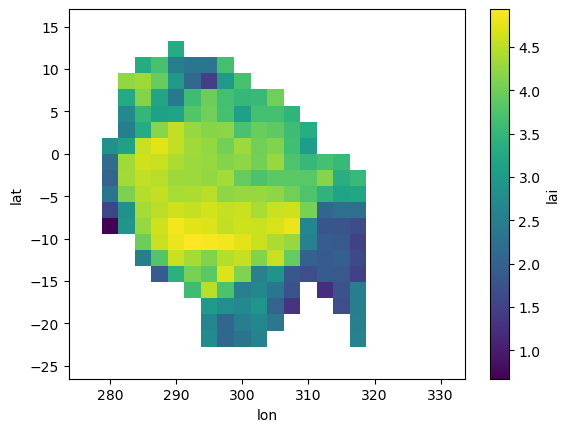

In [36]:
modis_lai_regrid.plot(x="lon",y="lat")

In [37]:
modis_lai_regrid.to_netcdf(out_path+obs_file)

In [ ]:
## Other ILAMB LAI datasets
#obs_file='cao2023_lai.nc' -- done
#obs_file='ilamb_modis_lai_0.5x0.5.nc' -- done
#obs_file='avhrr_lai_0.5x0.5.nc'
# GEDI
#obs_file='OLS_C50_Amazon_ALL_LAI_mean_nonull_cut.nc'

In [10]:
lai_gedi=xr.open_dataset(in_path+'OLS_C50_Amazon_ALL_LAI_mean_nonull_cut.nc')

In [13]:
lai_gedi.isel(band=0).__xarray_dataarray_variable__

<xarray.DataArray '__xarray_dataarray_variable__' (lat: 300, lon: 353)> Size: 847kB
[105900 values with dtype=float64]
Coordinates:
    band     int64 8B 1
  * lon      (lon) float64 3kB -78.55 -78.45 -78.35 ... -43.55 -43.45 -43.35
  * lat      (lat) float64 2kB 10.55 10.45 10.35 10.25 ... -19.15 -19.25 -19.35
Attributes:
    AREA_OR_POINT:  Area
    grid_mapping:   spatial_ref

In [14]:
gedi_lai_regrid=conservative_regrid(lai_gedi.isel(band=0),'__xarray_dataarray_variable__',fates.lat.data,fates.lon.data)

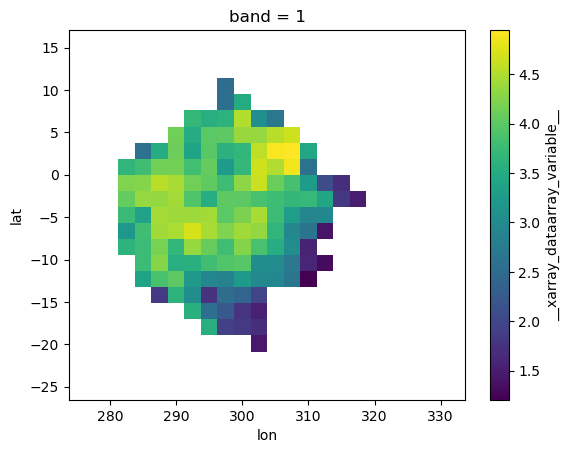

In [15]:
gedi_lai_regrid.plot(x="lon",y="lat")

In [16]:
gedi_lai_regrid.to_netcdf(out_path+'OLS_C50_Amazon_ALL_LAI_mean_nonull_cut.nc')

In [5]:
lai_avhrr=xr.open_dataset(in_path+'avhrr_lai_0.5x0.5.nc')

In [7]:
lai_avhrr_tavg=lai_avhrr.sel(time=slice("1990","2010")).mean(dim="time")

In [8]:
avhrr_lai_regrid = conservative_regrid(lai_avhrr_tavg,'lai',fates.lat.data,fates.lon.data)

In [9]:
avhrr_lai_regrid.to_netcdf(out_path+'avhrr_lai_0.5x0.5.nc')

In [9]:
lai_cao2023=xr.open_dataset(in_path+'cao2023_lai.nc')

In [10]:
lai_cao2023_tavg=lai_cao2023.lai.sel(time=slice("1990","2014")).mean(dim="time")

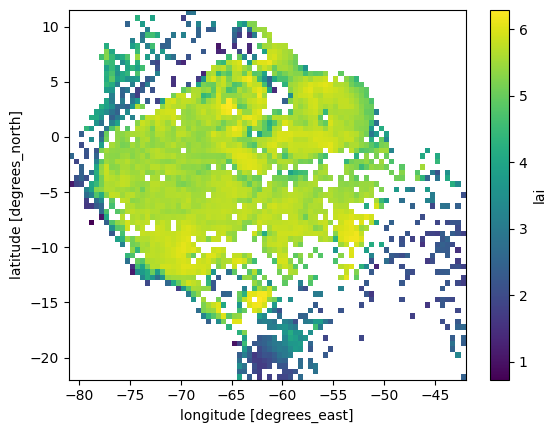

In [20]:
lai_cao2023_tavg.plot(x="lon",y="lat")

In [27]:
cao2023_lai_regrid = conservative_regrid(lai_cao2023_tavg,'lai',fates.lat.data,fates.lon.data)

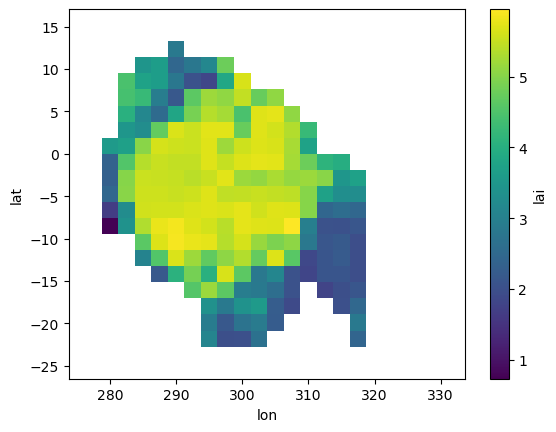

In [29]:
cao2023_lai_regrid.plot(x="lon",y="lat")

In [30]:
cao2023_lai_regrid.to_netcdf(out_path+'cao2023_lai.nc')

In [ ]:
## ILAMB ET
#obs_file='GLEAMv3.3a_et.nc'
#obs_file='MOD16A2_et.nc'
#obs_file='modis_et_0.5x0.5.nc'

In [17]:
gleam_et=xr.open_dataset(in_path+'GLEAMv3.3a_et.nc')

In [18]:
et_gleam_tavg=gleam_et.et.sel(time=slice("1990","2014")).mean(dim="time")

In [19]:
gleam_et_regrid = conservative_regrid(et_gleam_tavg,'et',fates.lat.data,fates.lon.data)

In [20]:
gleam_et_regrid.to_netcdf(out_path+'GLEAMv3.3a_et.nc')

In [ ]:
## ILAMB LH
#obs_file='WECANN_LH.nc'
#obs_file='fluxcom_LH.nc'
#obs_file='CLASS_LH.nc'
#obs_file='DOLCE_LH.nc'